# Import packages

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from igor2 import binarywave as bw
import glob
import pickle
from pathlib import Path
from matplotlib.transforms import Bbox
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
import re
from scipy.interpolate import RBFInterpolator

In [4]:
from scipy.fftpack import fft2, ifft2, fftshift
from scipy.stats import binned_statistic
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter, maximum_filter, minimum_filter
import matplotlib.patches as patches

from scipy.spatial import Voronoi
from skimage.filters import gaussian
from skimage.feature import peak_local_max
from skimage.morphology import disk
from shapely.geometry import Polygon

In [5]:
import warnings
warnings.filterwarnings('ignore')

## Data preparation

In [6]:
def flatten_image(image, order=1, axis=1):

    flattened_image = np.copy(image)

    num_lines = image.shape[axis]
    length = image.shape[1 - axis]
    x = np.arange(length)

    for i in range(num_lines):
        line = image[i, :] if axis == 0 else image[:, i]
        coeffs = np.polyfit(x, line, deg=order)
        fit_line = np.polyval(coeffs, x)

        if axis == 0:
            flattened_image[i, :] = line - fit_line
        else:
            flattened_image[:, i] = line - fit_line

    return flattened_image

def normalizer(img):
    img = np.asarray(img, dtype=float)
    return (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-12)

# Define once
red_white_blue = LinearSegmentedColormap.from_list(
    "red_white_blue",
    ["blue", "white", "red"]
)

## Grid analysis

In [15]:
with open("auconi_mfm_grid.pkl", "rb") as f:
    data = pickle.load(f)


print(data.keys())

dict_keys(['positions', 'images'])


In [16]:
images = data["images"]
positions = data["positions"]

images = np.array(images[:23])
positions = np.array(positions[:23])  # overwrite the same variable

print(images.shape)
print(positions.shape)

(23, 5, 256, 256)
(23, 2)


vmin=-0.00, vcenter=0.00, vmax=0.00


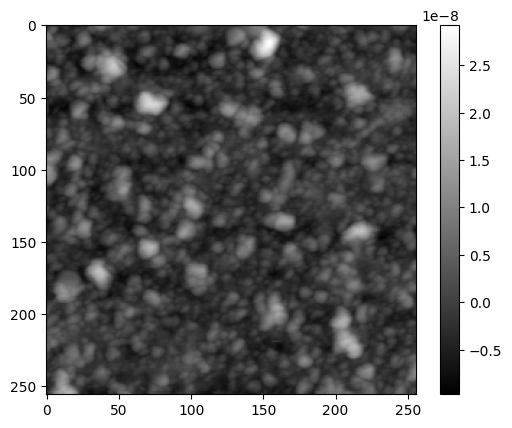

In [63]:
slice_img = images[22][0]

vmin = np.min(slice_img)
vmax = np.max(slice_img)
vcenter = (vmin + vmax) / 2      

# Create adaptive normalization
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

print(f"vmin={vmin:.2f}, vcenter={vcenter:.2f}, vmax={vmax:.2f}")

plt.imshow(slice_img, cmap=red_white_blue, norm=norm)
plt.imshow(slice_img, cmap="gray")
plt.colorbar()
plt.show()

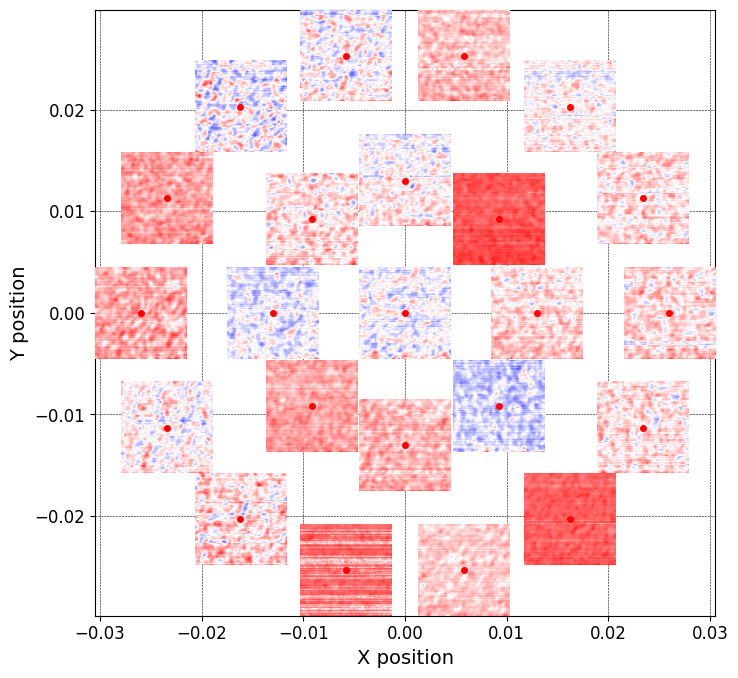

In [18]:
channel = 4   # choose which channel to display, e.g. 0 = height, 4 = MFM
scale = 0.009   # scaling factor for image size in plot units

fig, ax = plt.subplots(figsize=(8, 8))

for img, (x, y) in zip(images, positions):
    h, w = img[channel].shape
    
    # extent defines where each image is placed
    extent = [x - scale/2, x + scale/2, y - scale/2, y + scale/2]
    
    vmin = np.min(img[channel])
    vmax = np.max(img[channel])
    vcenter = (vmin + vmax) / 2      

    # Create adaptive normalization
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    #ax.imshow(img[channel], cmap="grey", extent=extent, origin="lower", zorder=5)
    ax.imshow(img[channel], cmap=red_white_blue, norm=norm, extent=extent, origin="upper", zorder=5)
    
    ax.plot(x, y, "ro", markersize=4, zorder=10)  # optional: mark center with red dot

ax.set_aspect("equal")
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)


ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)

#plt.savefig(out_dir / "GT_MagneticResponces_as_deposit_Realmap.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()


## Correlation length

In [20]:
def _radial_profile(arr):
    H, W = arr.shape
    cy, cx = H//2, W//2
    y, x = np.indices(arr.shape)
    r = np.sqrt((y-cy)**2 + (x-cx)**2)
    r_flat = r.ravel()
    a_flat = arr.ravel()
    bins = np.arange(0, r_flat.max()+1)  # 1 px bins
    prof, edges, _ = binned_statistic(r_flat, a_flat, statistic='mean', bins=bins)
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers, prof

def correlation_length_nm(height_img, pixel_size_nm,
                          smooth_sigma_px=3,
                          thresholds=(0.6, 0.2, 0.1)):
                            # 0.2 for mag
                            # 0.5 for hight

    I = np.asarray(height_img, dtype=float)
    if not np.isfinite(I).any():
        return np.nan

    # detrend: remove mean (you can also high-pass if there is a slow background)
    I = I - np.nanmean(I)

    # window to reduce FFT wrap-around artifacts
    wy = np.hanning(I.shape[0])[:, None]
    wx = np.hanning(I.shape[1])[None, :]
    W = wy * wx
    Iw = I * W

    # autocorrelation via Wiener–Khinchin
    F = fft2(Iw)
    P = np.abs(F)**2
    C = fftshift(np.real(ifft2(P)))

    # normalize by zero-lag value (center), not by global max
    cy, cx = C.shape[0]//2, C.shape[1]//2
    c0 = C[cy, cx]
    if not np.isfinite(c0) or c0 == 0:
        return np.nan
    Cn = C / c0

    # radial average -> C(r); smooth to suppress noise/oscillations
    r_px, Cr = _radial_profile(Cn)
    if Cr is None or not np.isfinite(Cr).any():
        return np.nan
    Cr = gaussian_filter1d(Cr, sigma=smooth_sigma_px)

    # find first crossing for any acceptable threshold
    for thr in thresholds:
        idx = np.where(Cr <= thr)[0]
        if idx.size > 0:
            i = idx[0]
            if i == 0:
                r_star_px = r_px[i]
            else:
                # linear interpolate between (i-1) and i
                y1, y2 = Cr[i-1], Cr[i]
                x1, x2 = r_px[i-1], r_px[i]
                if y2 == y1:
                    r_star_px = x2
                else:
                    t = (thr - y1)/(y2 - y1)
                    r_star_px = x1 + t*(x2 - x1)
            return float(r_star_px * pixel_size_nm)

    # no crossing found -> correlation length exceeds FOV; return NaN or FOV
    # return np.nan
    return float(min(I.shape) * pixel_size_nm)  # or comment this and return NaN


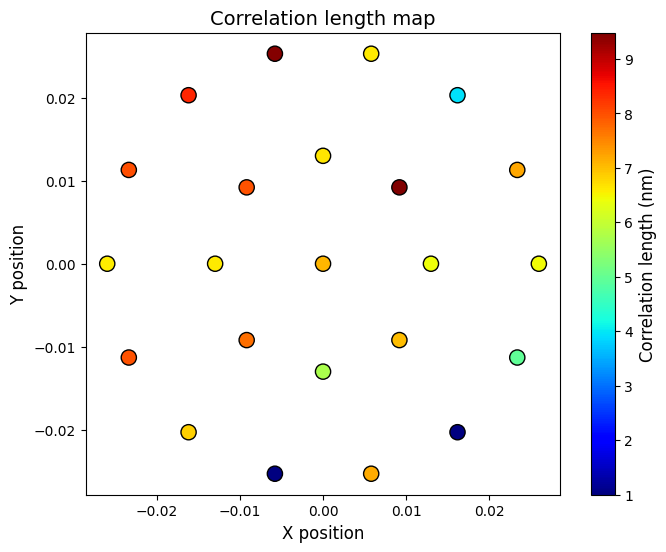

In [21]:
# --- set parameters ---
pixel_size_nm = 2   # change to your actual calibration!
channel = 4         # 0 = height, 4 = MFM phase, etc.

correlation_lengths = []

# --- run over all images ---
for img in images:
    L = correlation_length_nm(img[channel], pixel_size_nm=pixel_size_nm)
    correlation_lengths.append(L)

correlation_lengths = np.array(correlation_lengths)

# --- plot map ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    positions[:, 0], positions[:, 1],
    c=correlation_lengths, cmap="jet",
    s=120, edgecolor="k"
)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Correlation length (nm)", fontsize=12)

ax.set_xlabel("X position", fontsize=12)
ax.set_ylabel("Y position", fontsize=12)
ax.set_title("Correlation length map", fontsize=14)
ax.set_aspect("equal")

plt.show()

In [22]:
# Find indices of min and max correlation length
idx_max = np.nanargmax(correlation_lengths)   # ignore NaNs
idx_min = np.nanargmin(correlation_lengths)

# Values
L_max = correlation_lengths[idx_max]
L_min = correlation_lengths[idx_min]

# Corresponding positions
pos_max = positions[idx_max]
pos_min = positions[idx_min]

print(f"Max correlation length: {L_max:.2f} nm at index {idx_max}, position {pos_max}")
print(f"Min correlation length: {L_min:.2f} nm at index {idx_min}, position {pos_min}")


Max correlation length: 9.48 nm at index 2, position [0.0092 0.0092]
Min correlation length: 1.00 nm at index 19, position [-0.0058 -0.0253]


How the maxima look

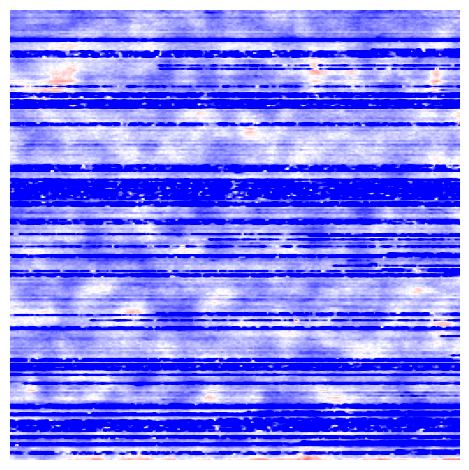

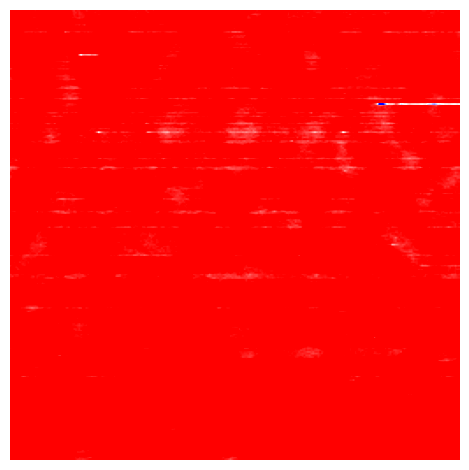

--------------------
Max corr length
9.48 nm
pos=[0.0092 0.0092], idx=2
--------------------
Min corr length
1.00 nm
pos=[-0.0058 -0.0253], idx=19


In [23]:
# Min image
#plt.imshow(images[idx_min][channel], cmap="grey")
plt.imshow(images[idx_min][channel], cmap=red_white_blue, norm=norm)

plt.axis("off")
# plt.savefig(out_dir / "min_mag_size_0.039 0._asd.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

# Max image
#plt.imshow(images[idx_max][channel], cmap="grey")
plt.imshow(images[idx_max][channel], cmap=red_white_blue, norm=norm)
# axes[1].set_title(f"Max corr length\n{L_max:.2f} nm\npos={pos_max}, idx={idx_max}")
plt.axis("off")
# plt.savefig(out_dir / "max_mag_size_-0.039  0._asd.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

print("-" * 20)
print(f"Max corr length\n{L_max:.2f} nm\npos={pos_max}, idx={idx_max}")

print("-" * 20)
print(f"Min corr length\n{L_min:.2f} nm\npos={pos_min}, idx={idx_min}")

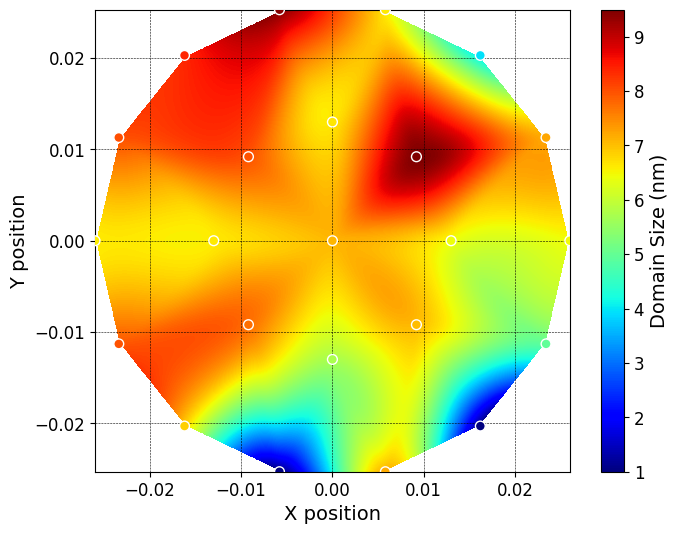

In [24]:
# Create a regular grid covering your positions
grid_x, grid_y = np.mgrid[
    positions[:,0].min():positions[:,0].max():2000j,   # 200 points along X
    positions[:,1].min():positions[:,1].max():2000j    # 200 points along Y
]

# Interpolate values onto the grid
grid_z = griddata(positions, correlation_lengths, (grid_x, grid_y), method="cubic")

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_z.T, extent=(
        positions[:,0].min(), positions[:,0].max(),
        positions[:,1].min(), positions[:,1].max()
    ),
    origin="lower", cmap="jet", aspect="equal", zorder=1)

# Overlay measurement points
sc = ax.scatter(
    positions[:,0], positions[:,1],
    c=correlation_lengths,
    cmap="jet",
    edgecolor="w",
    s=50,
    zorder=5
)

# Colorbar
cb = plt.colorbar(im, ax=ax)
cb.set_label("Domain Size (nm)", fontsize=14)
cb.ax.tick_params(labelsize = 12)

ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)
# ax.set_title("GT_corr MAP length map", fontsize=14)
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)

#plt.savefig(out_dir / "GT_DomainSize_as_deposit.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()



## <font color = "darkviolet">**LLM based Code Reasoning & Testing**</font>

In [ ]:
import google.generativeai as genai
from PIL import Image
genai.configure(api_key="Your API Key")
import time
from matplotlib.colors import LogNorm

In [ ]:
def analyze_image(image, question):

    # Convert NumPy → PIL if needed
    if isinstance(image, np.ndarray):
        if image.dtype != np.uint8:
            image = image - np.min(image)
            image = image / (np.max(image) + 1e-8)
            image = (image * 255).astype(np.uint8)
        if image.ndim == 2:
            image = Image.fromarray(image, mode="L")
        else:
            image = Image.fromarray(image)

    # Downscale very large images
    max_side = 512
    w, h = image.size
    if max(w, h) > max_side:
        scale = max_side / max(w, h)
        image = image.resize((int(w * scale), int(h * scale)))

    # Use a lightweight, image-capable model
    model = genai.GenerativeModel("models/gemini-2.5-flash")
    response = model.generate_content([question, image])

    return response.text


In [118]:
img = images[22][0]
result = analyze_image(img, "What features are visible in this microscopy image?")
print(result)

This microscopy image reveals a highly textured and non-uniform surface. Key features visible include:

1.  **Numerous Particles/Grains/Nanostructures:** The surface is densely populated with small, bright features that appear to be elevated particles or grains.
2.  **Size Variation:** While most features are relatively small and uniformly sized, there are also noticeably larger, more prominent bright features scattered across the surface. These could be larger particles or agglomerations of smaller ones.
3.  **Irregular Shapes:** The individual features generally have irregular, somewhat rounded, or granular shapes, rather than distinct geometric forms.
4.  **Dense and Random Distribution:** The features are closely packed and appear to be randomly distributed across the entire field of view, with no obvious pattern or alignment.
5.  **Surface Roughness:** The presence of these varied elevated features indicates a significant surface roughness or topography. The brighter areas suggest

In [59]:
img = images[22][0]
result = analyze_image(img, "what machine learning methods can you try to calculate the roughness? which one is better?")
print(result)

The image you've provided appears to be a surface topography map, likely from an Atomic Force Microscope (AFM) or similar technique, where pixel intensity (or color map) represents height. Calculating roughness from such an image using machine learning is a **regression problem**, where the goal is to predict a continuous numerical value (e.g., Ra, Rq, Rz, etc.) based on the input image.

Here are the machine learning methods you can try, broadly categorized:

### 1. Traditional Machine Learning with Feature Engineering

This approach involves manually extracting relevant numerical features from the image and then feeding these features into a traditional ML model.

**Feature Engineering Steps:**

*   **Statistical Features:**
    *   **Primary Roughness Parameters:** While the goal is to *predict* these, sometimes simpler approximations or related statistical values can be features.
    *   **Histogram-based:** Mean, median, standard deviation (RMS roughness is essentially the standar

In [61]:
result = analyze_image(img, "can you write the code to calculate roughness using Fourier Transform?")
print(result)

Calculating surface roughness using the Fourier Transform is a powerful approach, especially when you want to understand the *spatial frequency content* of the roughness, not just a single aggregate value. The most common metric related to the Fourier Transform is the **Root Mean Square (RMS) roughness**, often denoted as $R_q$ or $\sigma$.

According to **Parseval's Theorem**, the total energy of a signal in the spatial domain is equal to the total energy in the frequency domain. For surface height data, this means the variance of the surface heights is directly related to the sum of the magnitudes squared of its Fourier coefficients.

Here's how we can do it:

1.  **Load the Image:** Interpret the grayscale pixel values as height data. Brighter pixels mean higher, darker mean lower.
2.  **Pre-process (Optional but good practice):** Subtract the mean height from the entire surface. This ensures the data is centered around zero, which aligns with the interpretation of the Fourier Trans

In [ ]:
def calculate_roughness_from_fourier(img):

    # 1️⃣ Load and normalize image
    # img = Image.open(image_path).convert("L")
    height_map = np.array(img, dtype=float)

    # Optional: scale to real height units if known
    # height_map *= pixel_to_height
    height_map *= 2.0 # each pixel is 2nm in size

    # 2️⃣ Remove mean (detrend)
    height_map -= np.mean(height_map)

    # 3️⃣ Compute 2D Fourier Transform and Power Spectral Density (PSD)
    fft_image = np.fft.fft2(height_map)
    fft_shift = np.fft.fftshift(fft_image)
    psd2D = np.abs(fft_shift) ** 2

    # 4️⃣ Compute RMS roughness from PSD
    M, N = height_map.shape
    rms_roughness = np.sqrt(np.sum(psd2D) / (M * N)**2)

    # 5️⃣ Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].imshow(height_map, cmap='gray')
    ax[0].set_title("Height Map (Grayscale)")
    ax[0].axis("off")

    im = ax[1].imshow(psd2D + 1e-8, cmap='inferno', norm=LogNorm())
    ax[1].set_title("Power Spectral Density (log scale)")
    ax[1].axis("off")
    fig.colorbar(im, ax=ax[1], shrink=0.8)
    plt.tight_layout()
    plt.show()

    print(f"✅ RMS Roughness: {rms_roughness:.4f} (in pixel or physical units)")
    
    return rms_roughness

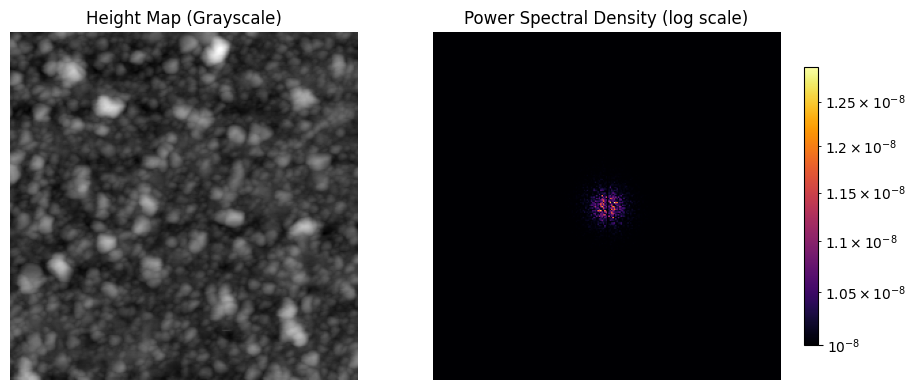

✅ RMS Roughness: 0.0000 (in pixel or physical units)
RMS Roughness = 8.716882478793139e-09


In [81]:
img = images[22][0]

rms = calculate_roughness_from_fourier(img)
print("RMS Roughness =", rms)

In [119]:
result = analyze_image(img, "does the image edges effect the roughness calculation? how do I avoid that in the calculation")
print(result)

Yes, the image edges **can absolutely affect roughness calculations**, especially in surface metrology images like the one you've provided (which appears to be an AFM or similar surface topography scan).

Here's why and how to avoid it:

### Why Image Edges Can Affect Roughness Calculation:

1.  **Instrumental Artifacts:**
    *   **Scan Edge Effects:** AFM or profilometer scanners can exhibit non-linearity, drift, or "ringing" phenomena near the scan boundaries, leading to artificially higher or lower values along the edges.
    *   **Scanner Reversal:** When the scanner changes direction, there can be slight overshoots or delays, visible as lines or slight elevation changes at the scan edges.
    *   **Leveling Issues:** If the image is leveled (e.g., plane-fitted or line-by-line flattened), the fitting algorithm might be less accurate at the very edges due to fewer surrounding data points, potentially introducing a slight tilt or curvature that isn't real.

2.  **Boundary Conditions

<font color = "red" >Slding window to avoid edge effect</font>

In [96]:
def calculate_roughness_from_fourier_2(img):

    # 1️⃣ Convert image to float height map
    height_map = np.array(img, dtype=float)

    # Scale to real height units (each pixel = 2 nm)
    height_map *= 2.0

    # 2️⃣ Remove mean (detrend)
    height_map -= np.mean(height_map)

    # 3️⃣ Apply 2D Hann window to reduce edge discontinuities
    M, N = height_map.shape
    wy = np.hanning(M)[:, None]  # column vector
    wx = np.hanning(N)[None, :]  # row vector
    window = wy * wx             # outer product → 2D window
    height_map_windowed = height_map * window

    # 4️⃣ Compute 2D FFT and Power Spectral Density (PSD)
    fft_image = np.fft.fft2(height_map_windowed)
    fft_shift = np.fft.fftshift(fft_image)
    psd2D = np.abs(fft_shift) ** 2

    # 5️⃣ Compute RMS roughness using PSD (Parseval's theorem)
    rms_roughness = np.sqrt(np.sum(psd2D) / (M * N)**2)*10e9

    # # 6️⃣ Visualization
    # fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    # ax[0].imshow(height_map, cmap='gray')
    # ax[0].set_title("Original Height Map")
    # ax[0].axis("off")

    # ax[1].imshow(height_map_windowed, cmap='gray')
    # ax[1].set_title("After 2D Hann Windowing")
    # ax[1].axis("off")

    # im = ax[2].imshow(psd2D + 1e-8, cmap='inferno', norm=LogNorm())
    # ax[2].set_title("Power Spectral Density (log scale)")
    # ax[2].axis("off")
    # fig.colorbar(im, ax=ax[2], shrink=0.8)

    # plt.tight_layout()
    # plt.show()

    # print(f"✅ RMS Roughness: {rms_roughness:.4f} nm")
    return rms_roughness


In [97]:
img = images[22][0]

rms = calculate_roughness_from_fourier_2(img)
print("RMS Roughness =", rms)

RMS Roughness = 30.553992997165047


<font color = "red" >Whole map</font>

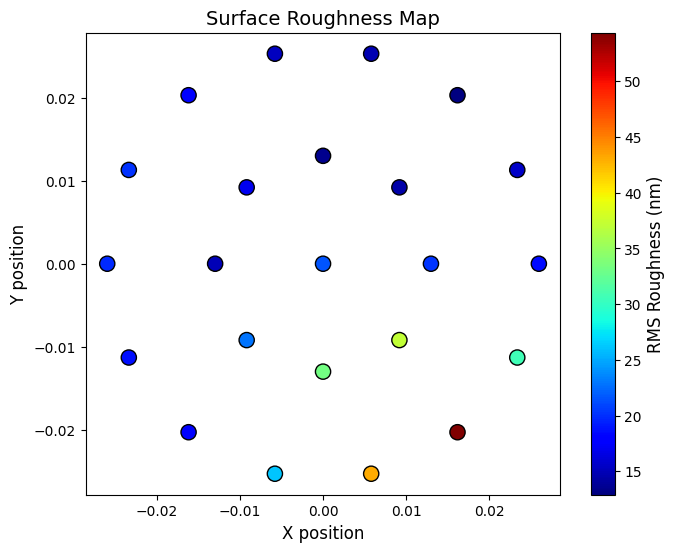

In [98]:
# --- parameters ---
pixel_size_nm = 2   # calibration: 2 nm per pixel
channel = 0         # e.g., 0 = height, 4 = MFM phase, etc.

roughness_values = []

# --- run over all images ---
for img in images:
    # compute RMS roughness (in nm) for each image
    R = calculate_roughness_from_fourier_2(img[channel])
    roughness_values.append(R)

roughness_values = np.array(roughness_values)

# --- plot roughness map ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    positions[:, 0], positions[:, 1],
    c=roughness_values, cmap="jet",
    s=120, edgecolor="k"
)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("RMS Roughness (nm)", fontsize=12)

ax.set_xlabel("X position", fontsize=12)
ax.set_ylabel("Y position", fontsize=12)
ax.set_title("Surface Roughness Map", fontsize=14)
ax.set_aspect("equal")

plt.show()


Max roughness: 54.37 nm at index 21, position [ 0.0162 -0.0203]
Min roughness: 12.89 nm at index 11, position [0.0162 0.0203]


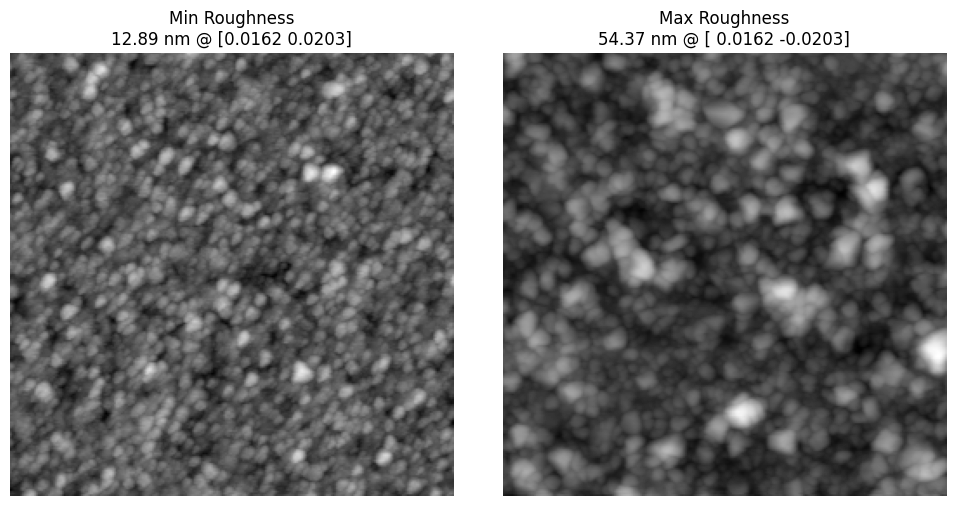

In [100]:
# Find indices of min and max correlation length
idx_max = np.nanargmax(roughness_values)
idx_min = np.nanargmin(roughness_values)

# Values
R_max = roughness_values[idx_max]
R_min = roughness_values[idx_min]

# Corresponding positions
pos_max = positions[idx_max]
pos_min = positions[idx_min]

print(f"Max roughness: {R_max:.2f} nm at index {idx_max}, position {pos_max}")
print(f"Min roughness: {R_min:.2f} nm at index {idx_min}, position {pos_min}")


# --- plot both images ---
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Left: minimum roughness image
ax[0].imshow(images[idx_min][channel], cmap="gray")
ax[0].set_title(f"Min Roughness\n{R_min:.2f} nm @ {pos_min}")
ax[0].axis("off")

# Right: maximum roughness image
ax[1].imshow(images[idx_max][channel], cmap="gray")
ax[1].set_title(f"Max Roughness\n{R_max:.2f} nm @ {pos_max}")
ax[1].axis("off")

plt.tight_layout()
plt.show()

<font color = "red" >Results accuracy check with Gemeni</font>

In [107]:
def comparsion(image1, question, image2=None):

    def preprocess(image):
        """Convert NumPy → PIL and normalize to uint8 (no resizing)."""
        if isinstance(image, np.ndarray):
            if image.dtype != np.uint8:
                image = image - np.min(image)
                image = image / (np.max(image) + 1e-8)
                image = (image * 255).astype(np.uint8)
            if image.ndim == 2:
                image = Image.fromarray(image, mode="L")
            else:
                image = Image.fromarray(image)
        return image

    # Prepare inputs for model
    img1 = preprocess(image1)
    inputs = [question, img1]

    # Add second image if provided
    if image2 is not None:
        img2 = preprocess(image2)
        inputs.append(img2)
        question = f"Compare these two images. {question}"

    # Run Gemini model
    model = genai.GenerativeModel("models/gemini-2.5-flash")
    response = model.generate_content(inputs)

    return response.text


In [108]:
image_1 = images[idx_min][0]
image_2 = images[idx_max][0]

result = comparsion(image_1, "What differences can you see between these samples?", image_2)
print(result)

These two images appear to be grayscale representations of surface topography, likely from microscopy techniques such as Atomic Force Microscopy (AFM) or Scanning Electron Microscopy (SEM), showing granular or particulate structures. Here are the key differences:

1.  **Feature Size and Distribution:**
    *   **Left Sample:** Shows smaller, more uniformly distributed, and relatively isolated features (grains/particles). The individual features appear finer.
    *   **Right Sample:** Exhibits larger, more irregularly shaped features. There's a wider distribution of sizes, with many larger grains and some evidence of smaller grains coalescing into bigger ones.

2.  **Roughness and Topography (Inferred from Brightness):**
    *   **Left Sample:** Appears smoother overall, with less variation in height (represented by brightness). The bright "peaks" are generally lower and less prominent.
    *   **Right Sample:** Appears significantly rougher, with more pronounced variations in height. T

<font color = "red" >Result validation with Gemeni</font>

In [109]:
result = comparsion(image_1, "Which one is rougher?", image_2)
print(result)

The image on the **right** appears rougher.

Here's why:
*   **Greater Contrast:** The image on the right shows more pronounced differences between the light (higher) and dark (lower) areas, suggesting larger variations in height.
*   **Larger Features:** The individual "grains" or features on the right appear larger and more distinct, indicating bigger bumps and valleys on the surface.
*   **Irregularity:** The features on the right seem more irregular in shape and size, which contributes to a perception of greater overall roughness.

The image on the left has smaller, more uniform features and less extreme contrast, suggesting a comparatively smoother or more finely textured surface.



<font color = "red" >Code accuracy check with Gemeni</font>

In [112]:
def test_code_with_gemini(code_str, description=None):

    # --- 2️⃣ Default test description ---
    if description is None:
        description = (
            "Test this code with dummy data, simulate expected behavior, "
            "and evaluate if it’s logically correct. Include improvements if needed."
        )

    # --- 3️⃣ Build the prompt safely ---
    prompt = (
        "You are a senior Python data-science expert and software tester.\n\n"
        "Your task:\n"
        "1. Review and conceptually execute the provided code with dummy or simulated data.\n"
        "2. Describe what type of input data you would create and why.\n"
        "3. Simulate realistic test results (without actual code execution).\n"
        "4. Evaluate correctness, logic, and possible numerical or design issues.\n"
        "5. Give a clear verdict: Is this approach valid? If not, why, and how to fix it?\n\n"
        f"Code to test:\n```\n{code_str}\n```\n\n"
        f"{description}\n\n"
        "Structure your response as:\n"
        "- **Test Setup**\n"
        "- **Simulated Results**\n"
        "- **Code Analysis**\n"
        "- **Verdict**"
    )


    model = genai.GenerativeModel("models/gemini-2.5-flash")
    response = model.generate_content(prompt)

    # --- 5️⃣ Print formatted report ---
    print("\n🧪 --- GEMINI CODE TEST REPORT --- 🧪\n")
    print(response.text)
    print("\n✅ --- END OF REPORT --- ✅\n")

    return response.text

In [ ]:
code_to_test = """

def calculate_roughness_from_fourier_2(img):

    # 1️⃣ Convert image to float height map
    height_map = np.array(img, dtype=float)

    # Scale to real height units (each pixel = 2 nm)
    height_map *= 2.0

    # 2️⃣ Remove mean (detrend)
    height_map -= np.mean(height_map)

    # 3️⃣ Apply 2D Hann window to reduce edge discontinuities
    M, N = height_map.shape
    wy = np.hanning(M)[:, None]  # column vector
    wx = np.hanning(N)[None, :]  # row vector
    window = wy * wx             # outer product → 2D window
    height_map_windowed = height_map * window

    # 4️⃣ Compute 2D FFT and Power Spectral Density (PSD)
    fft_image = np.fft.fft2(height_map_windowed)
    fft_shift = np.fft.fftshift(fft_image)
    psd2D = np.abs(fft_shift) ** 2

    # 5️⃣ Compute RMS roughness using PSD (Parseval's theorem)
    rms_roughness = np.sqrt(np.sum(psd2D) / (M * N)**2)*10e9

    # print(f"✅ RMS Roughness: {rms_roughness:.4f} nm")
    return rms_roughness

"""

    # Run the Gemini-based test
test_code_with_gemini(code_to_test)



🧪 --- GEMINI CODE TEST REPORT --- 🧪

As a senior Python data-science expert and software tester, I will review and test the provided `calculate_roughness_from_fourier_2` function.

### **Test Setup**

The function aims to calculate the RMS roughness of a surface from an image using Fourier analysis. RMS roughness is essentially the standard deviation of the surface height variations around its mean.

To test this, I will consider the core steps and potential pitfalls. Key areas of concern are unit consistency, the application of Parseval's theorem, and the impact of windowing.

**Input Data Description:**

I would create several types of input data to evaluate different aspects of the function:

1.  **Perfectly Flat Surface:** A 2D array of uniform values (e.g., `np.ones((4,4)) * 10`).
    *   **Purpose:** To verify that a flat surface yields an RMS roughness of 0 (or close to it, considering floating-point precision). This checks the detrending and baseline calculation.
2.  **Simple 

'As a senior Python data-science expert and software tester, I will review and test the provided `calculate_roughness_from_fourier_2` function.\n\n### **Test Setup**\n\nThe function aims to calculate the RMS roughness of a surface from an image using Fourier analysis. RMS roughness is essentially the standard deviation of the surface height variations around its mean.\n\nTo test this, I will consider the core steps and potential pitfalls. Key areas of concern are unit consistency, the application of Parseval\'s theorem, and the impact of windowing.\n\n**Input Data Description:**\n\nI would create several types of input data to evaluate different aspects of the function:\n\n1.  **Perfectly Flat Surface:** A 2D array of uniform values (e.g., `np.ones((4,4)) * 10`).\n    *   **Purpose:** To verify that a flat surface yields an RMS roughness of 0 (or close to it, considering floating-point precision). This checks the detrending and baseline calculation.\n2.  **Simple Ramp/Step Surface:** A

<font color = "red" >Test the code</font>


🧪 --- TESTING calculate_roughness_from_fourier --- 🧪



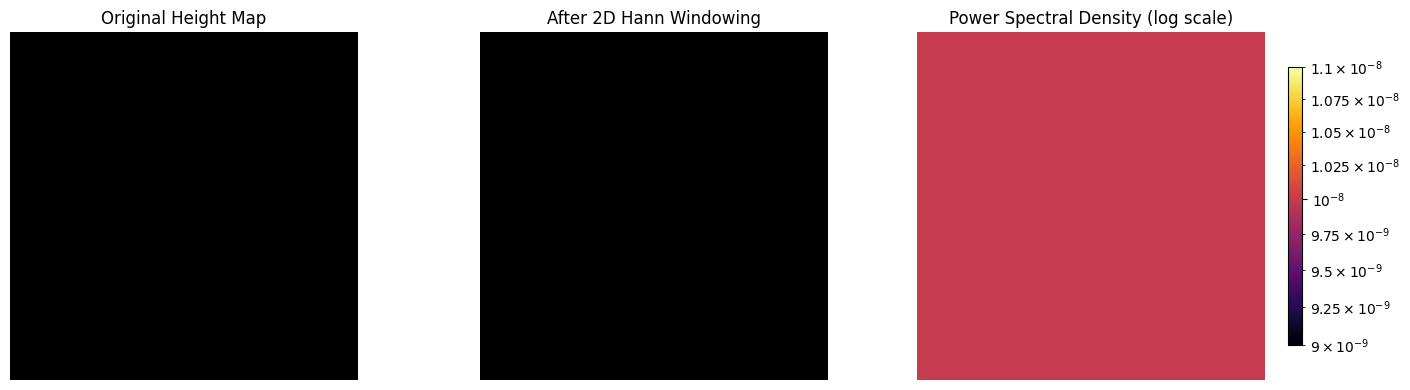

✅ RMS Roughness: 0.0000 nm
Flat surface        : RMS roughness = 0.000000


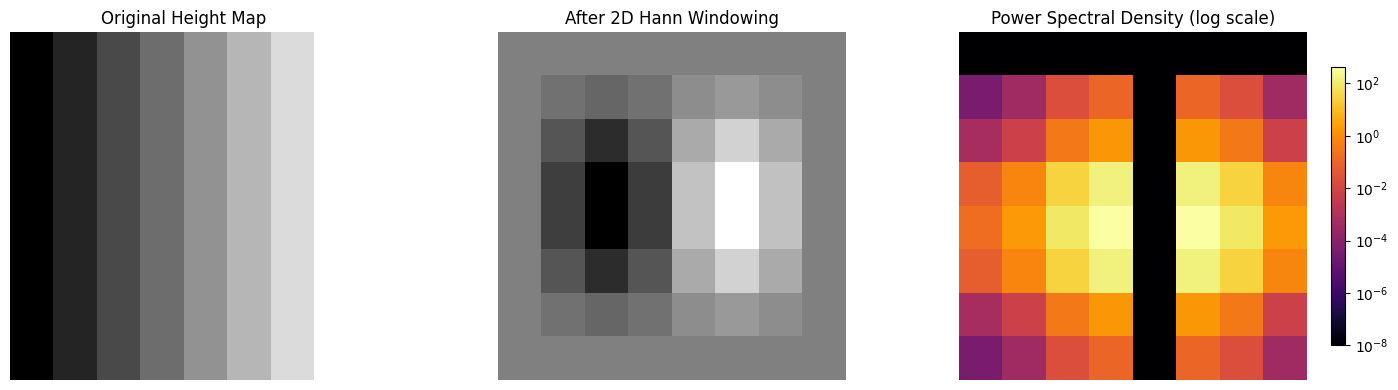

✅ RMS Roughness: 0.6501 nm
Linear ramp         : RMS roughness = 0.650107


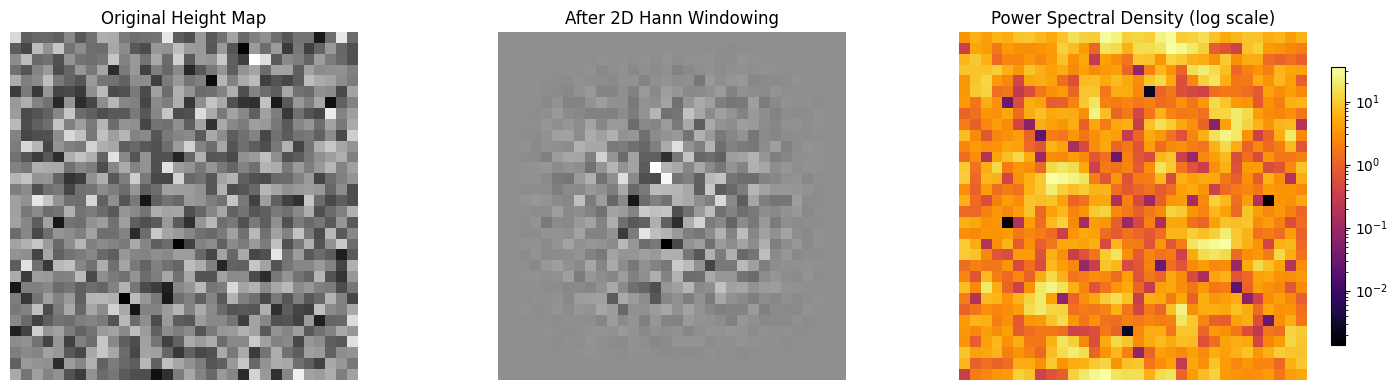

✅ RMS Roughness: 0.0689 nm
Noisy flat surface  : RMS roughness = 0.068900

✅ --- SUMMARY --- ✅

✔ Flat surface → near zero roughness ✅
✔ Ramp surface → higher roughness than flat ✅
✔ Noisy surface → small but nonzero roughness ✅

✅ --- END OF TESTS --- ✅



In [115]:
# 🧠 Test Harness Based on Gemini’s Review
def test_calculate_roughness_from_fourier():
    """
    Runs several synthetic tests based on Gemini’s conceptual validation:
    1. Flat surface
    2. Linear ramp
    3. Noisy flat surface
    """

    tests = {
        "Flat surface": np.ones((8, 8)) * 10,  # uniform plane
        "Linear ramp": np.tile(np.arange(8), (8, 1)),  # increasing x-gradient
        "Noisy flat surface": np.ones((32, 32)) * 50 + np.random.normal(0, 0.1, (32, 32)),
    }

    print("\n🧪 --- TESTING calculate_roughness_from_fourier --- 🧪\n")

    results = {}

    for name, img in tests.items():
        try:
            roughness = calculate_roughness_from_fourier(img)
            results[name] = roughness
            print(f"{name:<20}: RMS roughness = {roughness:.6f}")
        except Exception as e:
            results[name] = None
            print(f"{name:<20}: ❌ Error: {e}")

    print("\n✅ --- SUMMARY --- ✅\n")

    # Expected logical behavior
    flat = results.get("Flat surface", np.nan)
    ramp = results.get("Linear ramp", np.nan)
    noisy = results.get("Noisy flat surface", np.nan)

    if flat < 1e-6:
        print("✔ Flat surface → near zero roughness ✅")
    else:
        print(f"⚠ Flat surface roughness too high: {flat:.6e}")

    if ramp > flat:
        print("✔ Ramp surface → higher roughness than flat ✅")
    else:
        print(f"⚠ Ramp roughness not higher than flat: {ramp:.6e}")

    if noisy > flat:
        print("✔ Noisy surface → small but nonzero roughness ✅")
    else:
        print(f"⚠ Noise not producing expected small roughness: {noisy:.6e}")

    print("\n✅ --- END OF TESTS --- ✅\n")

test_calculate_roughness_from_fourier()


<font color = "red" >plot the final map on the grid</font>

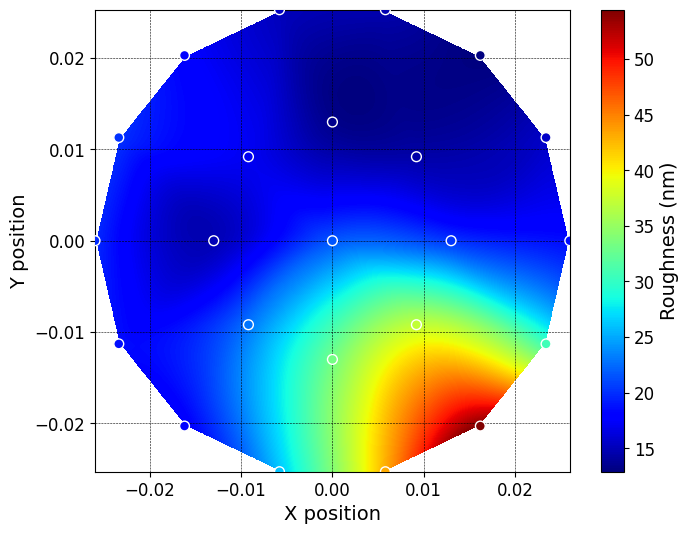

In [ ]:
# Create a regular grid covering your positions
grid_x, grid_y = np.mgrid[
    positions[:,0].min():positions[:,0].max():2000j,   # 200 points along X
    positions[:,1].min():positions[:,1].max():2000j    # 200 points along Y
]

# Interpolate values onto the grid
grid_z = griddata(positions, roughness_values, (grid_x, grid_y), method="cubic")

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_z.T, extent=(
        positions[:,0].min(), positions[:,0].max(),
        positions[:,1].min(), positions[:,1].max()
    ),
    origin="lower", cmap="jet", aspect="equal", zorder=1)

# Overlay measurement points
sc = ax.scatter(
    positions[:,0], positions[:,1],
    c=roughness_values,
    cmap="jet",
    edgecolor="w",
    s=50,
    zorder=5
)

# Colorbar
cb = plt.colorbar(im, ax=ax)
cb.set_label("Roughness (nm)", fontsize=14)
cb.ax.tick_params(labelsize = 12)

ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)
# ax.set_title("GT_corr MAP length map", fontsize=14)
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)

#plt.savefig(out_dir / "GT_DomainSize_as_deposit.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()
